# HDMap Watch — LiDAR to lane-map review

Explore a real Pittsburgh Argoverse 2 log, transform LiDAR from the vehicle frame into city coordinates, run the project's QA checks, and visualize the review queue.



In [1]:
from pathlib import Path
import importlib.metadata
import json
import platform
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from IPython.display import display
from hdmap_watch.etl import extract, transform

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "hdmap_watch").is_dir(), "Run from the repository root or notebooks directory"
LOG_ID = "02678d04-cc9f-3148-9f95-1ba66347dff9"
SPLIT = "val"
LOG_DIR = ROOT / "data" / "av2_sensor" / SPLIT / LOG_ID
FIG_DIR = ROOT / "notebooks" / "images"
OUT_DIR = ROOT / "out"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"PASS": "#159978", "REVIEW": "#dd642f", "map": "#273c55", "lidar": "#2688b8"}
artifacts = []

def save_figure(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    artifacts.append(str(path.relative_to(ROOT)))
    plt.show()
    plt.close(fig)
    print(path.relative_to(ROOT))

print(f"Python {platform.python_version()} | log {LOG_ID}")

Python 3.11.16 | log 02678d04-cc9f-3148-9f95-1ba66347dff9


## 1. Load the map and sensor observations

Download map, pose, calibration, and LiDAR files; omit camera images. Existing files with the expected size are reused. File counts below describe this run, not a canned result.

In [2]:
extract.download_log(SPLIT, LOG_ID, LOG_DIR)
log = transform.load_log(LOG_DIR)
assert log.lidar_files and len(log.pose), "The log needs LiDAR and pose data"
print(f"{len(log.lane_segments)} lane segments | {len(log.lidar_files)} sweeps | {len(log.pose)} poses")

all_bounds = np.concatenate([b.xyz for s in log.lane_segments
                             for b in (s.left_lane_boundary, s.right_lane_boundary)])
origin = all_bounds[:, :2].min(axis=0)

def draw_map(ax, status=None):
    for area in log.avm.vector_drivable_areas.values():
        xy = area.xyz[:, :2] - origin
        ax.fill(xy[:, 0], xy[:, 1], color="#edf1f4", zorder=0)
    for lane in log.lane_segments:
        color = COLORS[status[lane.id]] if status is not None else COLORS["map"]
        for boundary in (lane.left_lane_boundary, lane.right_lane_boundary):
            xy = boundary.xyz[:, :2] - origin
            ax.plot(xy[:, 0], xy[:, 1], color=color, lw=0.8, zorder=3)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("City x − map origin (m)")
    ax.set_ylabel("City y − map origin (m)")

def sample_indices(n, limit=80000):
    return np.linspace(0, n - 1, min(n, limit), dtype=int)

sweep_path = log.lidar_files[len(log.lidar_files) // 2]
raw = pd.read_feather(sweep_path)
xyz_ego = raw[["x", "y", "z"]].to_numpy()
xyz_city, intensity = transform.sweep_to_city(sweep_path, log.pose)
R, t = transform.pose_at(log.pose, int(sweep_path.stem))
np.testing.assert_allclose(xyz_city, xyz_ego @ R.T + t)
print(f"Example sweep: {sweep_path.name}, {len(raw):,} points")

92 lane segments | 157 sweeps | 2671 poses
Example sweep: 315969912159970000.feather, 86,886 points


## 2. Visualize LiDAR and the coordinate transformation

For row-vector points, `xyz_city = xyz_ego @ R.T + t`. Rotation comes from the scalar-first pose quaternion; translation places the vehicle in the city frame. Plot axes subtract one shared map origin for readable labels.

The implementation selects the first pose at or after a timestamp, capped at the final pose. This is a supplied-pose transformation, **not** estimated ICP alignment or correction of localization error.

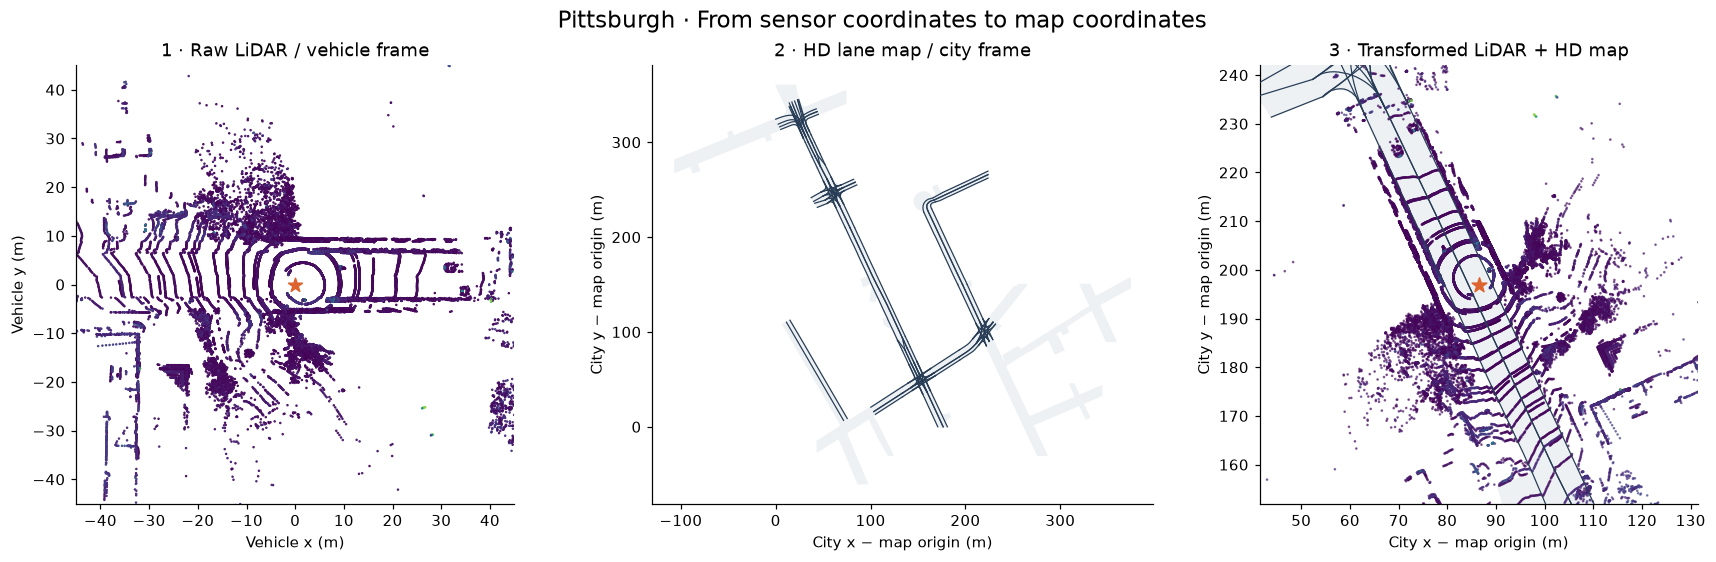

notebooks/images/01_coordinate_transformation.png


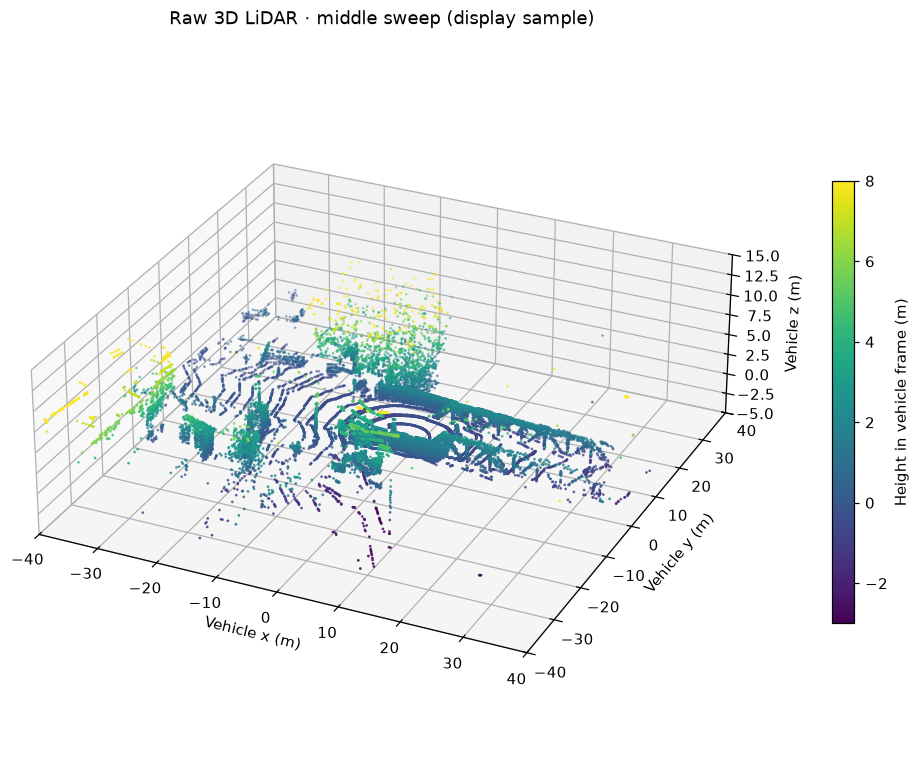

notebooks/images/02_lidar_3d.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
idx = sample_indices(len(raw))
axes[0].scatter(xyz_ego[idx, 0], xyz_ego[idx, 1], c=intensity[idx], cmap="viridis", s=0.4)
axes[0].scatter(0, 0, marker="*", s=90, color=COLORS["REVIEW"])
axes[0].set(xlim=(-45, 45), ylim=(-45, 45), xlabel="Vehicle x (m)", ylabel="Vehicle y (m)", title="1 · Raw LiDAR / vehicle frame")
axes[0].set_aspect("equal")
draw_map(axes[1])
axes[1].set_title("2 · HD lane map / city frame")
draw_map(axes[2])
xy = xyz_city[idx, :2] - origin
axes[2].scatter(xy[:, 0], xy[:, 1], c=intensity[idx], cmap="viridis", s=0.5, alpha=0.65, zorder=2)
ego = t[:2] - origin
axes[2].scatter(*ego, marker="*", s=100, color=COLORS["REVIEW"], zorder=5)
axes[2].set(xlim=(ego[0]-45, ego[0]+45), ylim=(ego[1]-45, ego[1]+45), title="3 · Transformed LiDAR + HD map")
fig.suptitle("Pittsburgh · From sensor coordinates to map coordinates", fontsize=15)
save_figure(fig, "01_coordinate_transformation")

fig = plt.figure(figsize=(11, 7), layout="constrained")
ax = fig.add_subplot(projection="3d")
inside = (np.abs(xyz_ego[:, 0]) <= 40) & (np.abs(xyz_ego[:, 1]) <= 40) & (xyz_ego[:, 2] >= -5) & (xyz_ego[:, 2] <= 15)
visible = np.flatnonzero(inside)
idx = visible[sample_indices(len(visible), 35000)]
cloud = ax.scatter(xyz_ego[idx, 0], xyz_ego[idx, 1], xyz_ego[idx, 2],
                   c=xyz_ego[idx, 2], cmap="viridis", s=0.6, vmin=-3, vmax=8)
ax.set(xlim=(-40, 40), ylim=(-40, 40), zlim=(-5, 15), xlabel="Vehicle x (m)",
       ylabel="Vehicle y (m)", zlabel="Vehicle z (m)", title="Raw 3D LiDAR · middle sweep (display sample)")
ax.set_box_aspect((2, 2, 0.7))
ax.view_init(elev=28, azim=-65)
fig.colorbar(cloud, ax=ax, shrink=0.6, label="Height in vehicle frame (m)")
save_figure(fig, "02_lidar_3d")

## 3. Run the point-cloud transformation

Accumulate all sweeps in city coordinates and filter ground points using the map's elevation raster. The brightest 10% of retained returns serve as candidate lane markings. Intensity is a heuristic: bright returns are not guaranteed to be lane paint.

This calls the same processing function as the ETL command. It holds the accumulated cloud in memory; large logs may need a future streaming implementation.

Processed 157 sweeps in 1.1s
Ground: 2,081,536 points | bright candidates: 210,168


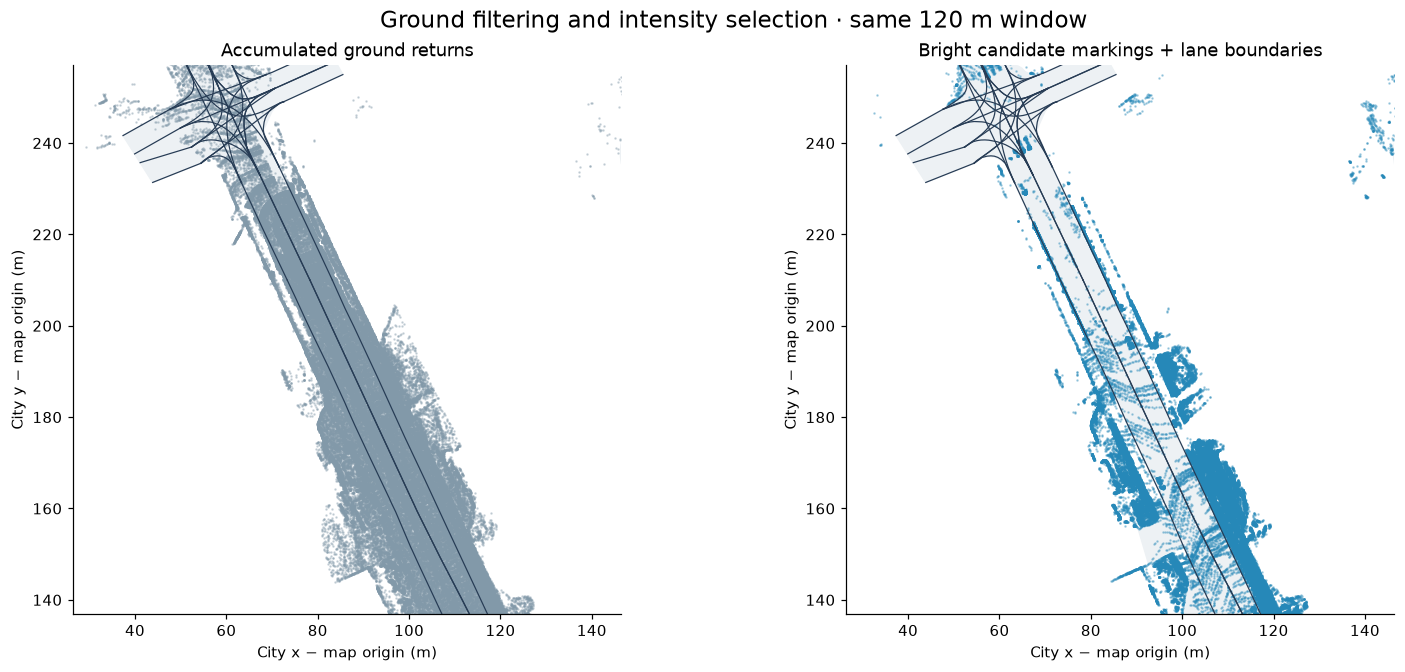

notebooks/images/03_ground_and_markings.png


In [4]:
start = time.perf_counter()
ground_pts, ground_intensity = transform.accumulate_ground_points(log)
assert len(ground_pts), "No ground points found"
bright_threshold = np.percentile(ground_intensity, transform.BRIGHT_PERCENTILE)
bright_mask = ground_intensity >= bright_threshold
bright_pts = ground_pts[bright_mask]
print(f"Processed {len(log.lidar_files)} sweeps in {time.perf_counter()-start:.1f}s")
print(f"Ground: {len(ground_pts):,} points | bright candidates: {len(bright_pts):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, pts, title, color in zip(axes, [ground_pts, bright_pts],
        ["Accumulated ground returns", "Bright candidate markings + lane boundaries"],
        ["#8299a9", COLORS["lidar"]]):
    draw_map(ax)
    idx = sample_indices(len(pts), 140000)
    xy = pts[idx, :2] - origin
    ax.scatter(xy[:, 0], xy[:, 1], s=0.4, alpha=0.4, color=color, zorder=2)
    ax.set(xlim=(ego[0]-60, ego[0]+60), ylim=(ego[1]-60, ego[1]+60), title=title)
fig.suptitle("Ground filtering and intensity selection · same 120 m window", fontsize=15)
save_figure(fig, "03_ground_and_markings")

## 4. Run geometry, topology, and neighbor checks

Geometry flags observed boundary vertices farther than 1 m from bright candidates; observation requires five candidates within 2 m. Topology flags missing references away from a 15 m tile-edge margin. Semantic QA checks declared left-neighbor boundary distances above 8 m.

One vote per check yields risk 0–3. `REVIEW` means at least one check fired. `PASS` means no flag; it does not prove correctness or sufficient observation.

Observed vertices: 622/1557
status
PASS      50
REVIEW    42


,segment_id,risk,status
0,56232884,1,REVIEW
1,56226898,1,REVIEW
2,56226943,1,REVIEW
3,56226945,1,REVIEW
4,56226956,1,REVIEW
5,56226973,1,REVIEW
6,56226981,1,REVIEW
7,56226995,1,REVIEW
8,56234102,1,REVIEW
9,56227003,1,REVIEW


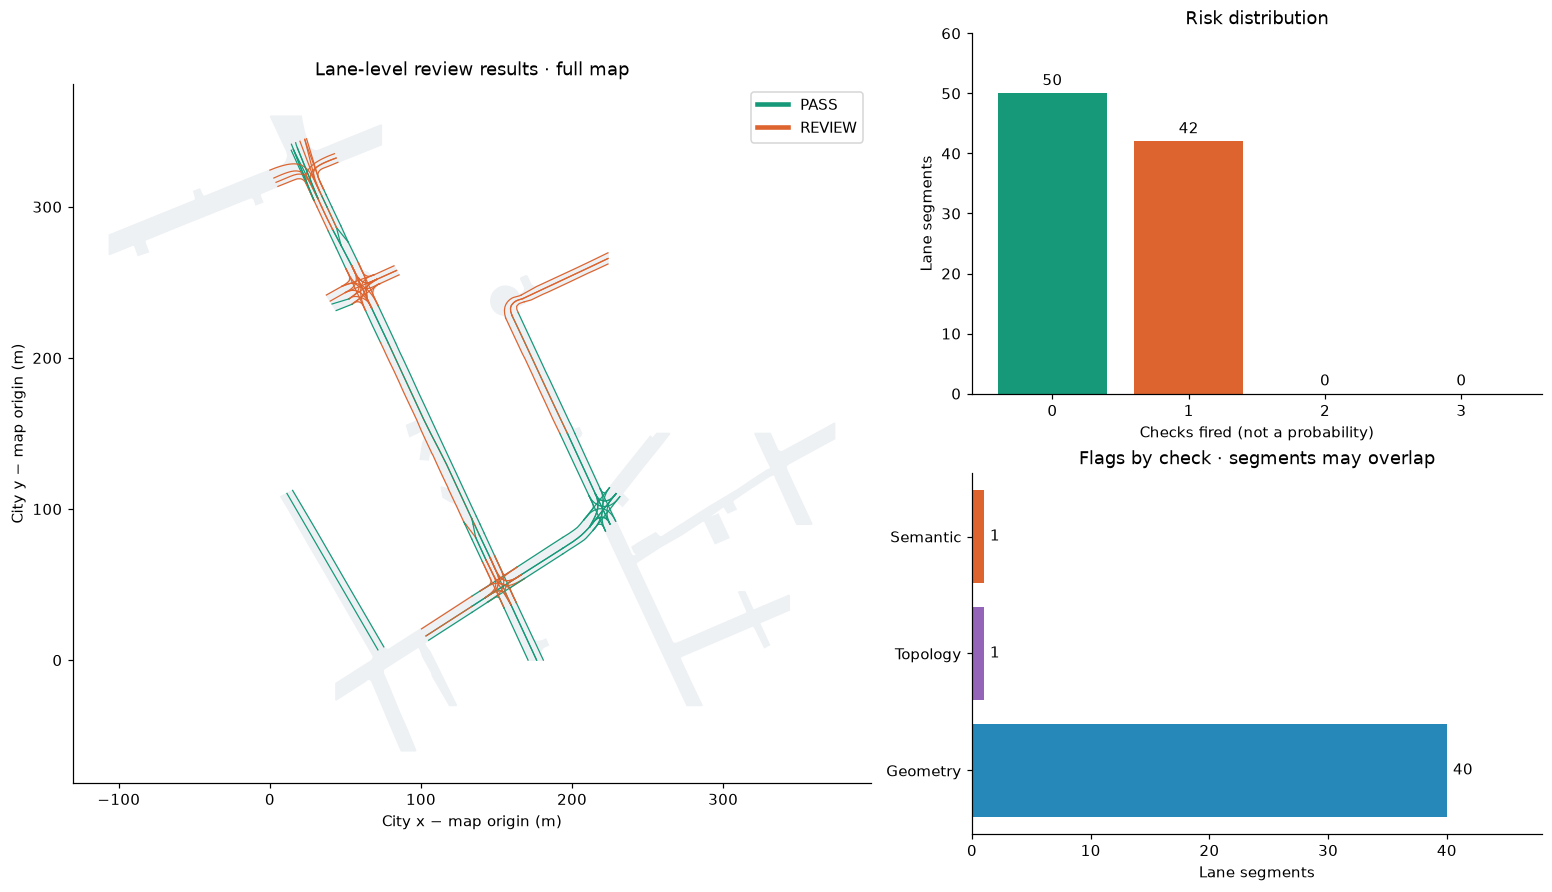

notebooks/images/04_qa_review_dashboard.png


In [5]:
geometry = transform.geometry_qa(log, ground_pts, ground_intensity)
topology = transform.topology_qa(log)
semantic = transform.semantic_qa(log)
queue = transform.risk_score(log, geometry, topology, semantic)
queue_path = OUT_DIR / f"review_queue_{LOG_ID}.csv"
queue.to_csv(queue_path, index=False)
status = queue.set_index("segment_id")["status"].to_dict()
checks = {"Geometry": len(geometry["flagged_segments"]),
          "Topology": len(topology["flagged_segments"]),
          "Semantic": len(semantic["flagged_segments"])}
print(f"Observed vertices: {geometry['n_observed']}/{geometry['n_vertices']}")
print(queue["status"].value_counts().to_string())
display(queue.head(10))

fig = plt.figure(figsize=(14, 8), layout="constrained")
grid = fig.add_gridspec(2, 2, width_ratios=[1.4, 1])
ax = fig.add_subplot(grid[:, 0])
draw_map(ax, status)
ax.set_title("Lane-level review results · full map")
ax.legend(handles=[Line2D([0], [0], color=COLORS[s], lw=3, label=s) for s in ["PASS", "REVIEW"]])
ax = fig.add_subplot(grid[0, 1])
counts = queue["risk"].value_counts().reindex(range(4), fill_value=0)
bars = ax.bar(counts.index, counts.values, color=[COLORS["PASS"]]+[COLORS["REVIEW"]]*3)
ax.bar_label(bars, padding=3)
ax.set(title="Risk distribution", xlabel="Checks fired (not a probability)", ylabel="Lane segments", xticks=range(4))
ax.margins(y=0.2)
ax = fig.add_subplot(grid[1, 1])
bars = ax.barh(list(checks), list(checks.values()), color=["#2688b8", "#9464b8", "#dd642f"])
ax.bar_label(bars, padding=4)
ax.set(title="Flags by check · segments may overlap", xlabel="Lane segments")
ax.margins(x=0.2)
save_figure(fig, "04_qa_review_dashboard")

## 5. Inspect the geometry evidence

The residual plot separates observed vertices from those with insufficient local evidence. The histogram uses only observed vertices. The detail view centers on the observed vertex with the largest residual, so it is an inspection example rather than a representative accuracy estimate.

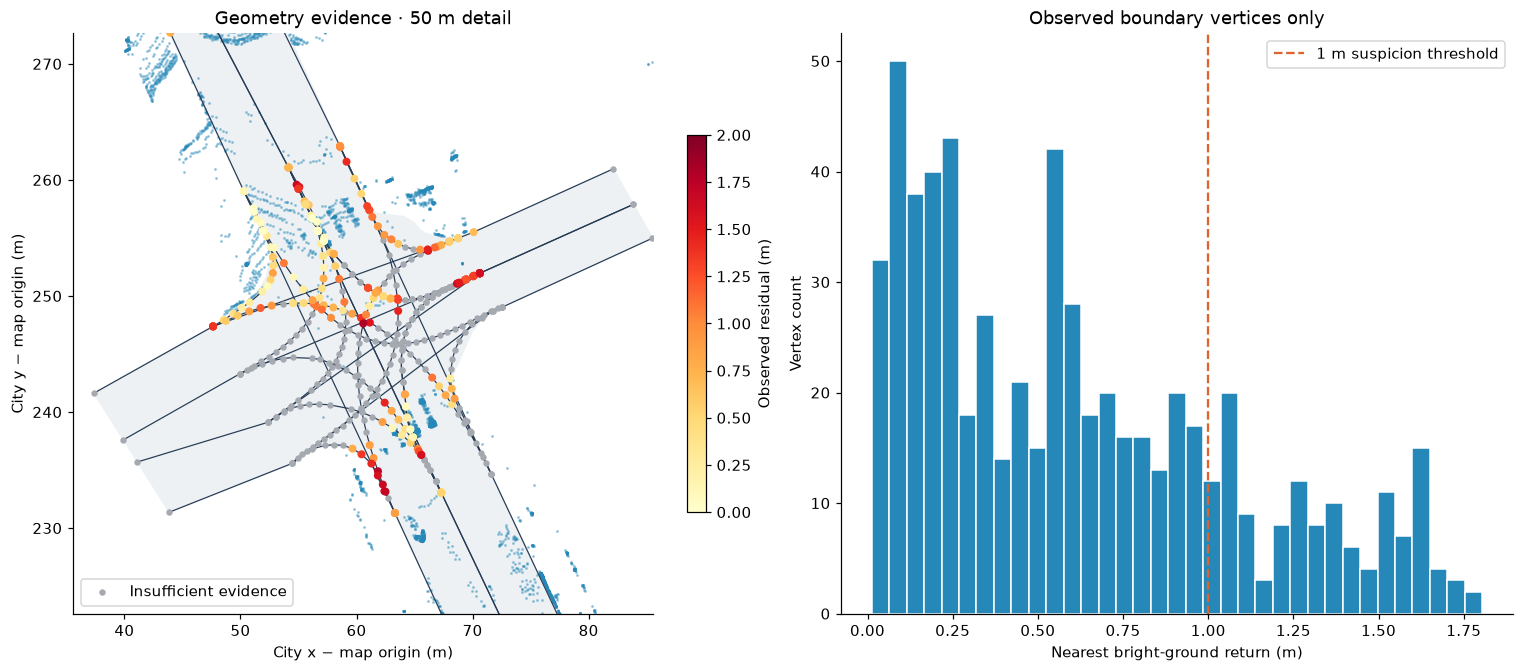

notebooks/images/05_geometry_evidence.png


In [6]:
verts = np.concatenate([b.xyz for lane in log.lane_segments
                        for b in (lane.left_lane_boundary, lane.right_lane_boundary)])
tree = cKDTree(bright_pts[:, :2])
residual, _ = tree.query(verts[:, :2])
observed = tree.query_ball_point(verts[:, :2], r=transform.OBSERVABILITY_RADIUS_M,
                                return_length=True) >= transform.OBSERVABILITY_MIN_POINTS
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
draw_map(axes[0])
focus = verts[np.argmax(np.where(observed, residual, -1)), :2] - origin if observed.any() else ego
idx = sample_indices(len(bright_pts), 180000)
xy = bright_pts[idx, :2] - origin
axes[0].scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.35, color=COLORS["lidar"], zorder=2)
xy = verts[:, :2] - origin
axes[0].scatter(xy[~observed, 0], xy[~observed, 1], s=10, color="#a5a9b0", zorder=4, label="Insufficient evidence")
points = axes[0].scatter(xy[observed, 0], xy[observed, 1], c=residual[observed], s=18,
                         cmap="YlOrRd", vmin=0, vmax=2, zorder=5)
axes[0].set(xlim=(focus[0]-25, focus[0]+25), ylim=(focus[1]-25, focus[1]+25), title="Geometry evidence · 50 m detail")
axes[0].legend(loc="lower left")
fig.colorbar(points, ax=axes[0], shrink=0.65, label="Observed residual (m)")
axes[1].hist(residual[observed], bins=35, color=COLORS["lidar"], edgecolor="white")
axes[1].axvline(transform.SUSPICION_THRESHOLD_M, color=COLORS["REVIEW"], ls="--", label="1 m suspicion threshold")
axes[1].set(title="Observed boundary vertices only", xlabel="Nearest bright-ground return (m)", ylabel="Vertex count")
axes[1].legend()
save_figure(fig, "05_geometry_evidence")